# AIRPATH-AI P0-2B — temporal robustness of Gap 1

Development/exploratory comparison of static vs hourly forecast-bucket-aware
arrival-time exposure across multiple departure clock times using
`C_xgboost_current_pm` and the P0-2A OD scenarios.

Load saved artifacts here. Regenerate with:
`python3 -m src.temporal_gap_analysis`.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT = PROJECT_ROOT / "data/processed/temporal_gap_analysis"

In [2]:
support = pd.read_csv(OUTPUT / "departure_support.csv")
departure_summary = pd.read_csv(OUTPUT / "departure_time_summary.csv")
mode_summary = pd.read_csv(OUTPUT / "mode_tolerance_departure_summary.csv")
decision = json.loads((OUTPUT / "evidence_decision.json").read_text())
support

,preferred_clock_time,analysis_date,departure_time,forecasting_origin,supported,exclusion_reason
0,06:00,2022-02-27,2022-02-27T06:00:00,2022-02-27T05:00:00,True,NaN
1,08:00,2022-02-27,2022-02-27T08:00:00,2022-02-27T07:00:00,True,NaN
2,12:00,2022-02-27,2022-02-27T12:00:00,2022-02-27T11:00:00,True,NaN
3,17:00,2022-02-27,2022-02-27T17:00:00,2022-02-27T16:00:00,True,NaN
4,20:00,2022-02-27,2022-02-27T20:00:00,2022-02-27T19:00:00,True,NaN


In [3]:
departure_summary

,departure_time,clock_time,scenario_mode_cases,mean_abs_pct_exposure_diff,mean_spearman,mean_kendall,mean_material_rank_change_pct,nontrivial_selection_difference_rate,mean_oracle_pct_improvement_when_differ,positive_oracle_gain_rate_when_differ
0,2022-02-27T06:00:00,06:00,60,3.797933,0.992460,0.980952,6.250000,0.050000,0.025680,0.333333
1,2022-02-27T08:00:00,08:00,60,3.868728,0.998016,0.994048,2.083333,0.016667,0.007608,1.000000
2,2022-02-27T12:00:00,12:00,60,17.063660,0.998810,0.996429,1.250000,0.000000,NaN,NaN
3,2022-02-27T17:00:00,17:00,60,4.709435,0.998413,0.995238,1.666667,0.000000,NaN,NaN
4,2022-02-27T20:00:00,20:00,60,0.957478,0.998810,0.996429,1.250000,0.000000,NaN,NaN


In [4]:
decision

{'classification': 'B. MIXED EVIDENCE',
 'rationale': 'Across supported departure times on 2022-02-27, nontrivial selection differences average 1.3% (range 0.0–5.0%). Strongest clock times: 06:00, 08:00; weakest: 20:00, 17:00. Mean oracle gain when selections differ is 0.02%. The pooled Gap 1 conclusion remains aligned with MIXED/weak evidence from P0-2A.',
 'criteria': {'evaluation_status': 'development_exploratory_not_untouched_final',
  'forecaster': 'C_xgboost_current_pm',
  'nontrivial_selection_difference_rate': 0.013333333333333334,
  'mean_oracle_percent_improvement_when_differ': 0.021162238573929182,
  'positive_oracle_gain_rate_when_differ': 0.5,
  'mean_spearman_static_vs_airpath': 0.9973015873015871,
  'mean_percentage_routes_with_material_rank_change': 2.5,
  'five_minute_selection_difference_percentage': 1.3333333333333335,
  'strong_differ_rate_ge_0_25': False,
  'strong_oracle_gain_ge_1_0': False,
  'strong_positive_gain_rate_ge_0_60': False,
  'mixed_differ_rate_ge_0_1

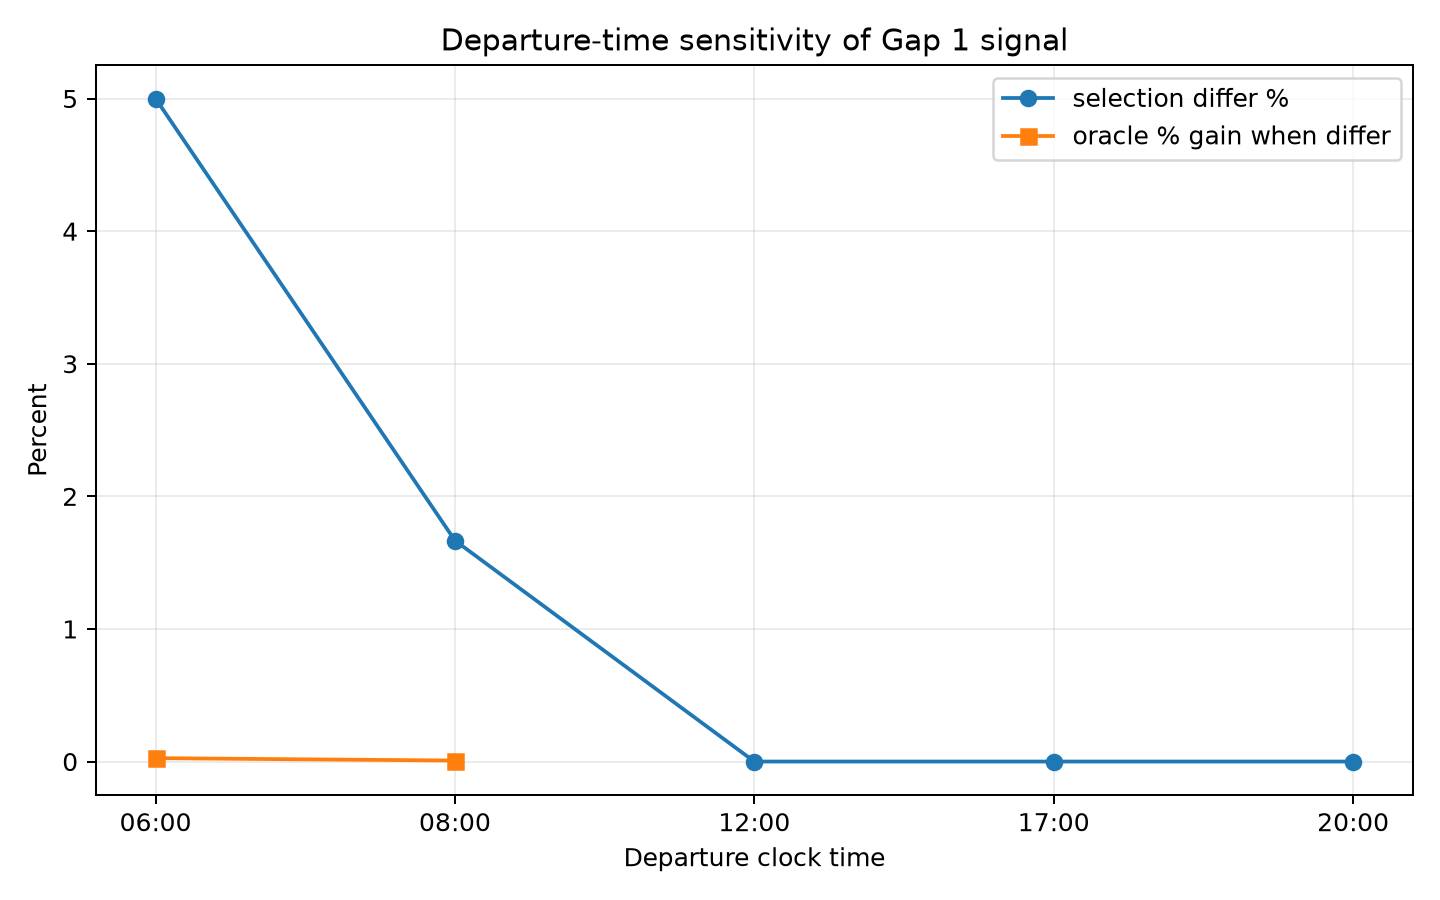

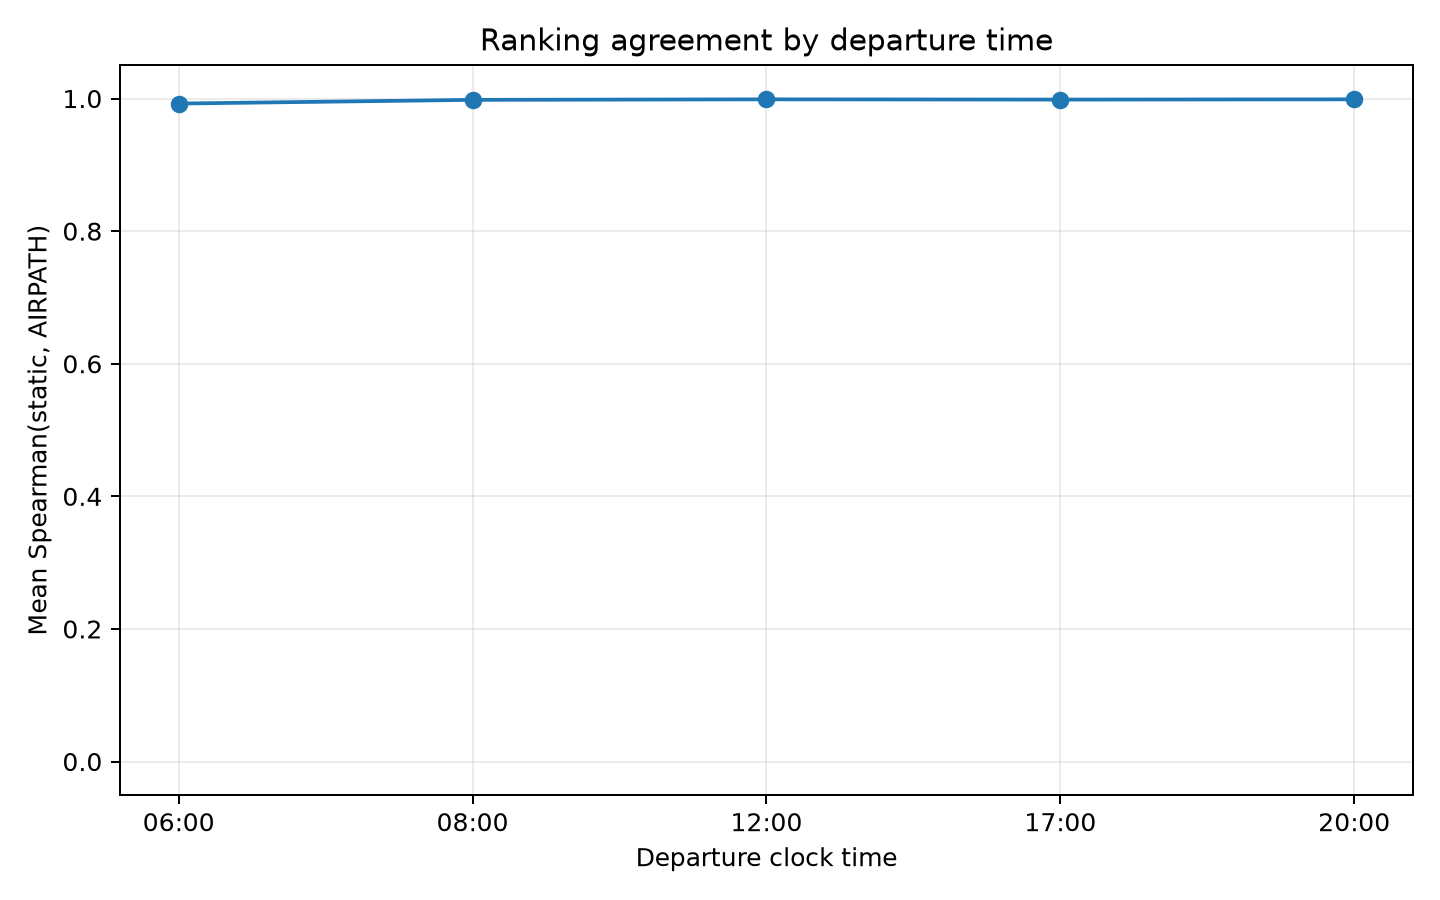

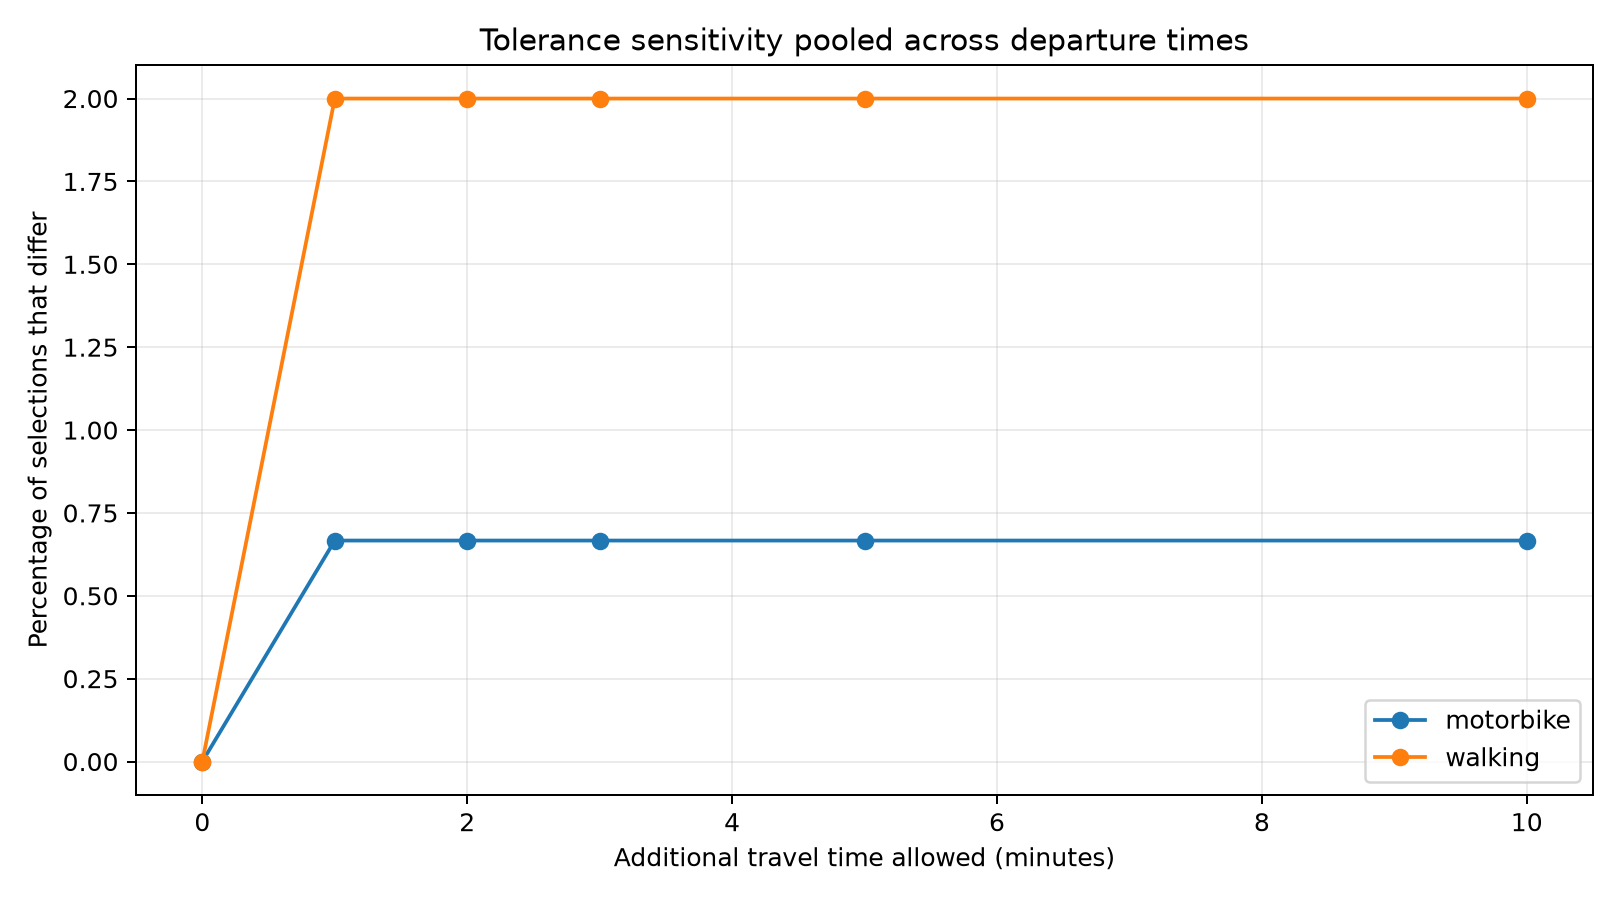

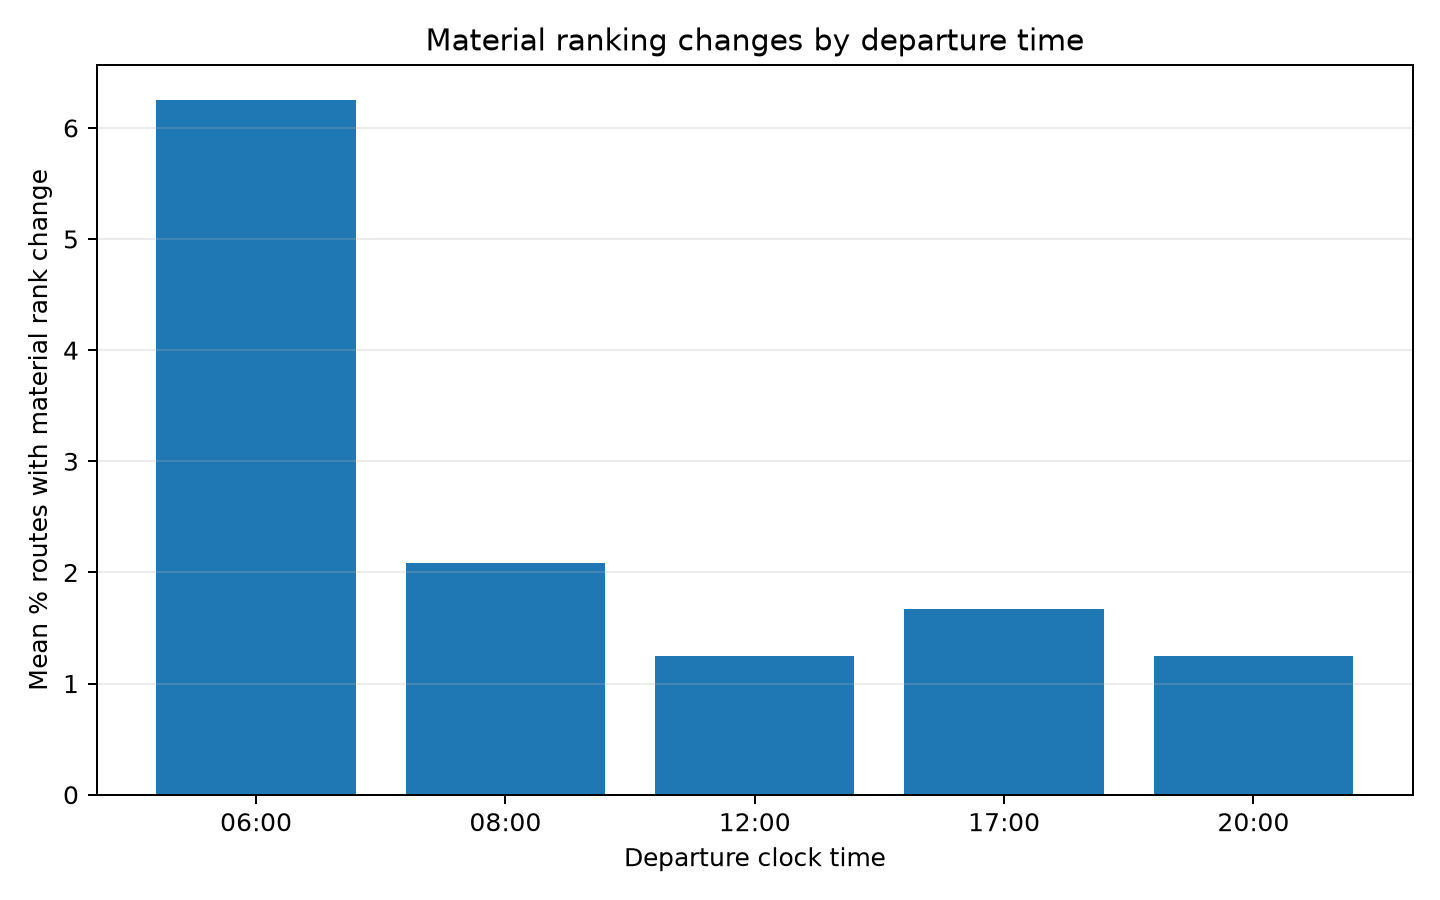

In [5]:
for name in (
    "departure_time_sensitivity.png",
    "ranking_by_departure.png",
    "tolerance_sensitivity.png",
    "material_rank_by_departure.png",
):
    display(Image(filename=str(OUTPUT / name)))